In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

project_root = current_dir.parents[2] 

if str(project_root) not in sys.path:
    
    sys.path.append(str(project_root))

print(f"Project root added: {project_root}")

Project root added: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique


Extracting /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/data/PATTERN/raw/PATTERN_v2.zip
Processing...
Done!


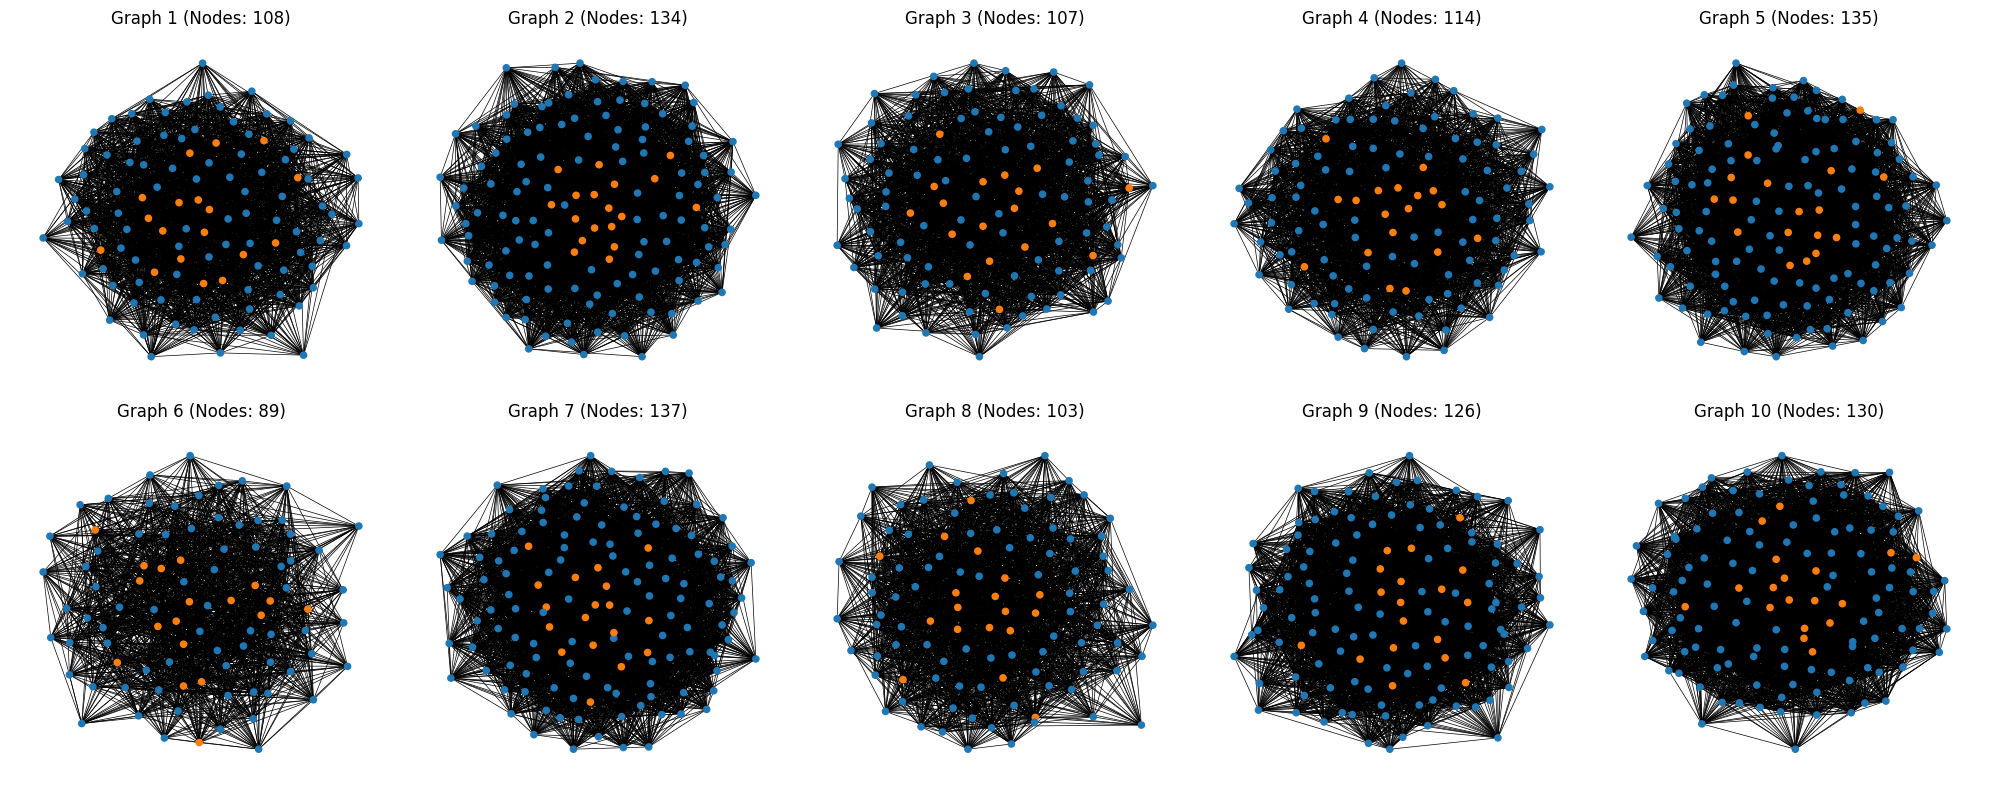

3


In [2]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.datasets import GNNBenchmarkDataset
from torch_geometric.utils import to_networkx
import os

data_dir = os.path.join(project_root, "data/")

# Load dataset
dataset = GNNBenchmarkDataset(root=data_dir, name='PATTERN', split='train')

def visualize_graphs(dataset, num_graphs=10):
    plt.figure(figsize=(20, 8))
    for i in range(num_graphs):
        data = dataset[i]
        # Convert PyG graph to NetworkX for visualization
        G = to_networkx(data, to_undirected=True)
        
        plt.subplot(2, 5, i + 1)
        # Use node labels for coloring: Label 0 (Blue), Label 1 (Orange)
        colors = ['#1f77b4' if l == 0 else '#ff7f0e' for l in data.y.tolist()]
        
        nx.draw(G, node_size=20, node_color=colors, width=0.5, with_labels=False)
        plt.title(f"Graph {i+1} (Nodes: {data.num_nodes})")
    
    plt.tight_layout()
    plt.show()

visualize_graphs(dataset)

print(dataset.num_features)

In [3]:
import torch.nn.functional as F
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d
from torch_geometric.nn import GINConv, global_add_pool

class GINNodeClassifier(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        
        super(GINNodeClassifier, self).__init__()

        self.conv1 = GINConv(Sequential(Linear(in_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = GINConv(Sequential(Linear(hidden_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = GINConv(Sequential(Linear(hidden_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn3 = BatchNorm1d(hidden_channels)

        self.conv4 = GINConv(Sequential(Linear(hidden_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn4 = BatchNorm1d(hidden_channels)

        self.classifier = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):

        x = x.float()

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.conv4(x, edge_index)
        x = self.bn4(x)
        x = F.relu(x)

        return self.classifier(x)

model = GINNodeClassifier(in_channels=dataset.num_features, hidden_channels=64, out_channels=2)
print(model)

GINNodeClassifier(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=

In [4]:
train_data = GNNBenchmarkDataset(root=data_dir, name='PATTERN', split='train')
val_data = GNNBenchmarkDataset(root=data_dir, name='PATTERN', split='val')
test_data = GNNBenchmarkDataset(root=data_dir, name='PATTERN', split='test')

print(f"Number of training graphs: {len(train_data)}")
print(f"Number of validation graphs: {len(val_data)}")
print(f"Number of test graphs: {len(test_data)}")

Number of training graphs: 10000
Number of validation graphs: 2000
Number of test graphs: 2000


Epoch 001 | Train loss: 0.4290 acc: 0.8155 | Val loss: 0.3937 acc: 0.8420 | LR: 1.00e-03
Epoch 002 | Train loss: 0.3056 acc: 0.8720 | Val loss: 0.4178 acc: 0.8619 | LR: 1.00e-03
Epoch 003 | Train loss: 0.2709 acc: 0.8884 | Val loss: 0.2810 acc: 0.8829 | LR: 1.00e-03
Epoch 004 | Train loss: 0.2647 acc: 0.8914 | Val loss: 0.2637 acc: 0.8914 | LR: 1.00e-03
Epoch 005 | Train loss: 0.2617 acc: 0.8928 | Val loss: 0.2725 acc: 0.8870 | LR: 1.00e-03
Epoch 006 | Train loss: 0.2602 acc: 0.8932 | Val loss: 0.2709 acc: 0.8881 | LR: 1.00e-03
Epoch 007 | Train loss: 0.2569 acc: 0.8948 | Val loss: 0.2708 acc: 0.8888 | LR: 1.00e-03
Epoch 008 | Train loss: 0.2535 acc: 0.8959 | Val loss: 0.2653 acc: 0.8912 | LR: 1.00e-03
Epoch 009 | Train loss: 0.2509 acc: 0.8971 | Val loss: 0.2942 acc: 0.8869 | LR: 1.00e-03
Epoch 010 | Train loss: 0.2486 acc: 0.8980 | Val loss: 0.2628 acc: 0.8916 | LR: 1.00e-03
Epoch 011 | Train loss: 0.2458 acc: 0.8994 | Val loss: 0.2888 acc: 0.8889 | LR: 1.00e-03
Epoch 012 | Train los

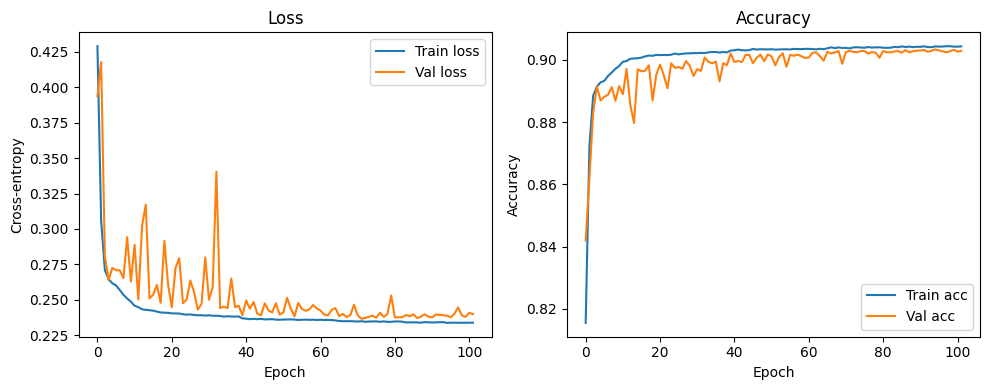

Test loss (best checkpoint): 0.2350
Test acc  (best checkpoint): 0.9035


In [5]:
import math
from copy import deepcopy
from pathlib import Path

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt

# --- Config ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr_init = 1e-3
lr_factor = 0.5
min_lr = 1e-6
num_epochs = 200
batch_size = 32

# Early stopping (on validation loss)
early_stop_patience = 30
min_delta = 0.0

# --- Loaders ---
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# --- Optimizer / scheduler ---
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr_init)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=lr_factor,
    patience=10,
    min_lr=min_lr,
 )

def _epoch_metrics(logits: torch.Tensor, y: torch.Tensor) -> tuple[float, float]:
    loss = F.cross_entropy(logits, y)
    pred = logits.argmax(dim=-1)
    acc = (pred == y).float().mean().item()
    return loss, acc

def train_one_epoch() -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_nodes = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(data.x, data.edge_index)
        y = data.y.view(-1).long()
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.detach().item() * y.numel()
        total_correct += int((logits.argmax(dim=-1) == y).sum().item())
        total_nodes += int(y.numel())

    return total_loss / max(total_nodes, 1), total_correct / max(total_nodes, 1)

@torch.no_grad()
def eval_loader(loader) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_nodes = 0
    for data in loader:
        data = data.to(device)
        logits = model(data.x, data.edge_index)
        y = data.y.view(-1).long()
        loss = F.cross_entropy(logits, y)

        total_loss += loss.item() * y.numel()
        total_correct += int((logits.argmax(dim=-1) == y).sum().item())
        total_nodes += int(y.numel())

    return total_loss / max(total_nodes, 1), total_correct / max(total_nodes, 1)

# --- Training loop (track best val loss) ---
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = math.inf
best_state = None
best_epoch = -1
epochs_no_improve = 0

ckpt_path = Path.cwd() /  'model_saves/best_gin_pattern_nodecls.pt'

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_one_epoch()
    va_loss, va_acc = eval_loader(val_loader)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    scheduler.step(va_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch:03d} | "
        f"Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | "
        f"Val loss: {va_loss:.4f} acc: {va_acc:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    # Best checkpoint + early stopping tracking
    if va_loss < (best_val_loss - min_delta):
        best_val_loss = va_loss
        best_state = deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(best_state, ckpt_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping at epoch {epoch} (best epoch {best_epoch}, best val loss {best_val_loss:.4f}).")
            break

print(f"\nBest val loss: {best_val_loss:.4f} (epoch {best_epoch})")
print(f"Saved best model to: {ckpt_path}")

# --- Plot curves (before test inference) ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train acc')
plt.plot(val_accs, label='Val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# --- Test inference using best model ---
if best_state is None:
    # Fallback: load from disk if available
    if ckpt_path.exists():
        best_state = torch.load(ckpt_path, map_location=device)
    else:
        raise RuntimeError('No best checkpoint available to run test inference.')

model.load_state_dict(best_state)
test_loss, test_acc = eval_loader(test_loader)
print(f"Test loss (best checkpoint): {test_loss:.4f}")
print(f"Test acc  (best checkpoint): {test_acc:.4f}")

## BCos GIN (edge-aware) on ZINC
This section defines a BCos version of GIN  so the comparison with the vanilla `GINConv` model above is faithful.

In [6]:
import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn.functional as F
from bcosgnn.explain import explain

## BCos readout

In [7]:
class Readout(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels=None,
        out_channels=1,
        b=2,
        max_out=1,
        agg: str = "sum",
    ):
        super().__init__()
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            hidden_channels = (
                [hidden_channels]
                if isinstance(hidden_channels, int)
                else hidden_channels
            )
            channels = [in_channels] + hidden_channels + [out_channels]
            self.readout = BcosSequential(
                *[
                    BcosLinear(d_in, d_out, b=b, max_out=max_out)
                    for d_in, d_out in zip(channels[:-1], channels[1:])
                ]
            )
        match agg:
            case "sum":
                self.agg = SumAggregation()
            case _:
                raise ValueError(f"Aggregation '{agg}' not supported.")

    def forward(self, x, batch):
        raise NotImplementedError


class AggThenReadout(Readout):
    def forward(self, x, batch):
        z = self.agg(x, batch)
        out = self.readout(z)
        return out


class ReadoutThenAgg(Readout):
    def forward(self, x, batch):
        z = self.readout(x)
        out = self.agg(z, batch)
        return out

## BCos GIN conv layer

In [8]:
class BcosGINConv(MessagePassing):
    def __init__(
        self,
        channels: list[int],
        b=2,
        max_out=1,
        eps: float = 0.0,
        train_eps: bool = False,
        **kwargs,
    ):
        kwargs.setdefault("aggr", "add")
        super().__init__(**kwargs)
        self.transform = BcosSequential(
            *[ 
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )
        self.initial_eps = eps
        if train_eps:
            self.eps = torch.nn.Parameter(torch.Tensor([eps]))
        else:
            self.register_buffer("eps", torch.Tensor([eps]))

    def forward(self, x, edge_index):
        x_original = x
        out = self.propagate(edge_index, x=x, size=None)
        out = (1 + self.eps) * x_original + out
        return self.transform(out)

    def message(self, x_j):
        return x_j

    def message_and_aggregate(self, adj_t, x):
        return matmul(adj_t, x, reduce=self.aggr)

## Bcos GNN


In [9]:
class BCosGNN(torch.nn.Module):
    def __init__(
        self,
        node_size: int,
        hidden_channels: int | list[int],
        conv_layer: type[MessagePassing],
        num_convs: int,
        readout: Readout,
        b: float = 2,
        max_out: int = 1,
        conv_kwargs: dict[str, Any] | None = None,
    ):
        super().__init__()
        if isinstance(hidden_channels, int):
            hidden_channels = [hidden_channels]
        conv_kwargs = conv_kwargs or {}
        self.lin_node = BcosLinear(
            node_size,
            hidden_channels[0],
        )
        self.convs = torch.nn.ModuleList(
            [
                conv_layer(
                    channels=hidden_channels,
                    b=b,
                    max_out=max_out,
                    **conv_kwargs,
                )
                for _ in range(num_convs)
            ]
        )
        self.readout = readout

    def forward(self, x, edge_index, batch):
        x = self.lin_node(x)
        for conv in self.convs:
            x = conv(x, edge_index)
        return self.readout(x, batch)

In [10]:
import math
from copy import deepcopy
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt
from bcos.modules import BcosLinear


class BCosGINNodeClassifier(nn.Module):
    """BCos analogue of the vanilla node-level GIN: 4 conv blocks + BN/ReLU + linear classifier."""
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, *, b: float = 2, max_out: int = 1):
        super().__init__()
        self.lin_node = BcosLinear(in_channels, hidden_channels, b=b, max_out=max_out)

        self.conv1 = BcosGINConv(channels=[hidden_channels, hidden_channels, hidden_channels], b=b, max_out=max_out)
        self.bn1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = BcosGINConv(channels=[hidden_channels, hidden_channels, hidden_channels], b=b, max_out=max_out)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.conv3 = BcosGINConv(channels=[hidden_channels, hidden_channels, hidden_channels], b=b, max_out=max_out)
        self.bn3 = nn.BatchNorm1d(hidden_channels)
        
        self.conv4 = BcosGINConv(channels=[hidden_channels, hidden_channels, hidden_channels], b=b, max_out=max_out)
        self.bn4 = nn.BatchNorm1d(hidden_channels)

        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        x = x.float()
        x = self.lin_node(x)

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.conv4(x, edge_index)
        x = self.bn4(x)
        x = F.relu(x)

        return self.classifier(x)









In [11]:
def _train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, device: torch.device) -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_nodes = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(data.x, data.edge_index)
        y = data.y.view(-1).long()
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.detach().item() * y.numel()
        total_correct += int((logits.argmax(dim=-1) == y).sum().item())
        total_nodes += int(y.numel())

    return total_loss / max(total_nodes, 1), total_correct / max(total_nodes, 1)


@torch.no_grad()
def _eval(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_nodes = 0
    for data in loader:
        data = data.to(device)
        logits = model(data.x, data.edge_index)
        y = data.y.view(-1).long()
        loss = F.cross_entropy(logits, y)

        total_loss += loss.item() * y.numel()
        total_correct += int((logits.argmax(dim=-1) == y).sum().item())
        total_nodes += int(y.numel())

    return total_loss / max(total_nodes, 1), total_correct / max(total_nodes, 1)

In [12]:
# --- Hyperparams (match vanilla style) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr_init = 1e-3
lr_factor = 0.5
min_lr = 1e-6
num_epochs = 200
batch_size = 32

early_stop_patience = 30
min_delta = 0.0

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

bcos_model = BCosGINNodeClassifier(in_channels=dataset.num_features, hidden_channels=64, out_channels=2, b=2, max_out=1).to(device)
optimizer = torch.optim.Adam(bcos_model.parameters(), lr=lr_init)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=lr_factor,
    patience=10,
    min_lr=min_lr,
 )

[BCosGIN] Epoch 001 | Train loss: 0.3499 acc: 0.8534 | Val loss: 0.2899 acc: 0.8818 | LR: 1.00e-03
[BCosGIN] Epoch 002 | Train loss: 0.2804 acc: 0.8839 | Val loss: 0.2724 acc: 0.8865 | LR: 1.00e-03
[BCosGIN] Epoch 003 | Train loss: 0.2698 acc: 0.8888 | Val loss: 0.2645 acc: 0.8909 | LR: 1.00e-03
[BCosGIN] Epoch 004 | Train loss: 0.2635 acc: 0.8916 | Val loss: 0.2655 acc: 0.8904 | LR: 1.00e-03
[BCosGIN] Epoch 005 | Train loss: 0.2608 acc: 0.8927 | Val loss: 0.2725 acc: 0.8870 | LR: 1.00e-03
[BCosGIN] Epoch 006 | Train loss: 0.2602 acc: 0.8932 | Val loss: 0.2605 acc: 0.8919 | LR: 1.00e-03
[BCosGIN] Epoch 007 | Train loss: 0.2580 acc: 0.8939 | Val loss: 0.2785 acc: 0.8839 | LR: 1.00e-03
[BCosGIN] Epoch 008 | Train loss: 0.2571 acc: 0.8942 | Val loss: 0.2755 acc: 0.8866 | LR: 1.00e-03
[BCosGIN] Epoch 009 | Train loss: 0.2569 acc: 0.8943 | Val loss: 0.2633 acc: 0.8904 | LR: 1.00e-03
[BCosGIN] Epoch 010 | Train loss: 0.2554 acc: 0.8951 | Val loss: 0.2540 acc: 0.8952 | LR: 1.00e-03
[BCosGIN] 

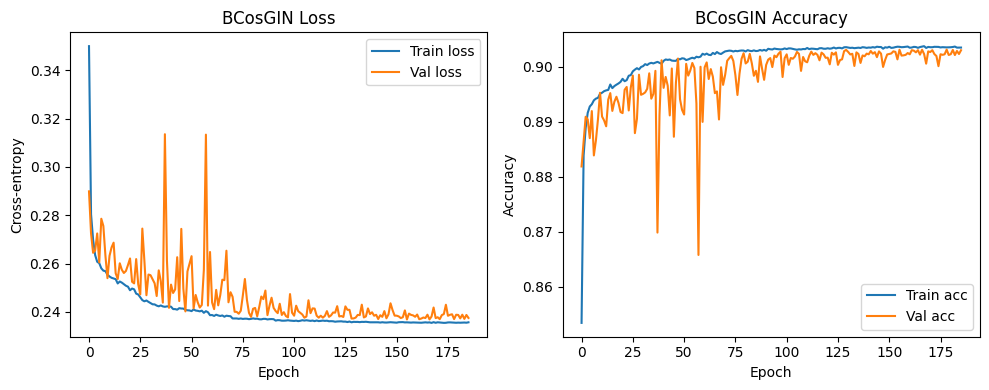

[BCosGIN] Test loss (best checkpoint): 0.2353
[BCosGIN] Test acc  (best checkpoint): 0.9030


In [13]:
# --- Training loop (node-level metrics, best by val loss) ---
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = math.inf
best_state = None
best_epoch = -1
epochs_no_improve = 0

ckpt_path = Path.cwd() / 'model_saves/best_bcos_gin_pattern_nodecls.pt'

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = _train_one_epoch(bcos_model, train_loader, optimizer, device)
    va_loss, va_acc = _eval(bcos_model, val_loader, device)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    scheduler.step(va_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"[BCosGIN] Epoch {epoch:03d} | "
        f"Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | "
        f"Val loss: {va_loss:.4f} acc: {va_acc:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    if va_loss < (best_val_loss - min_delta):
        best_val_loss = va_loss
        best_state = deepcopy(bcos_model.state_dict())
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(best_state, ckpt_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"[BCosGIN] Early stopping at epoch {epoch} (best epoch {best_epoch}, best val loss {best_val_loss:.4f}).")
            break

print(f"\n[BCosGIN] Best val loss: {best_val_loss:.4f} (epoch {best_epoch})")
print(f"[BCosGIN] Saved best model to: {ckpt_path}")

# --- Plot curves (before test inference) ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy')
plt.title('BCosGIN Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train acc')
plt.plot(val_accs, label='Val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('BCosGIN Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# --- Test inference using best model ---
if best_state is None:
    if ckpt_path.exists():
        best_state = torch.load(ckpt_path, map_location=device)
    else:
        raise RuntimeError('No best BCos checkpoint available to run test inference.')

bcos_model.load_state_dict(best_state)
test_loss, test_acc = _eval(bcos_model, test_loader, device)
print(f"[BCosGIN] Test loss (best checkpoint): {test_loss:.4f}")
print(f"[BCosGIN] Test acc  (best checkpoint): {test_acc:.4f}")